In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import chess.pgn

### An example for pgn file

[Event "Live Chess"]
[Site "Chess.com"]
[Date "2026.06.02"]
[White "Jupitercs"]
[Black "pano-2932"]
[Result "1-0"]
[WhiteElo "984"]
[BlackElo "934"]
[Termination "Jupitercs won by checkmate"]
[StartTime "14:24:47"]
[EndTime "14:40:45"]
[Link "https://www.chess.com/analysis/game/live/169603865950/analysis"]

1. d4 e6 2. Bf4 Nf6 3. e3 Bb4+ 4. c3 Be7 5. Nd2 O-O 6. Bd3 Nd5 7. Bg3 Bh4 8.
Bxh4 Qxh4 9. Ngf3 Qg4 10. O-O Nb6 11. Be2 Qf5 12. Nh4 Qf6 13. Nhf3 Nd5 14. Ne5
b6 15. Bf3 c6 16. Ne4 Qd8 17. Nd6 Nf6 18. Ndc4 Ba6 19. Be2 d5 20. Nd2 Bxe2 21.
Qxe2 Nbd7 22. c4 Nxe5 23. dxe5 Nd7 24. cxd5 cxd5 25. Rac1 Nxe5 26. Qh5 Nd7 27.
Nf3 Nf6 28. Qg5 Ne4 29. Qe5 Qc8 30. Rxc8 Raxc8 31. h3 Rc2 32. Nd4 Rxb2 33. Nxe6
Re8 34. Qxb2 Rxe6 35. Qd4 Re8 36. Qxd5 Nc3 37. Qd7 Kf8 38. Rc1 Ne2+ 39. Kf1 Nxc1
40. Qd6+ Kg8 41. Qc6 Rf8 42. Qxc1 Kh8 43. h4 Kg8 44. h5 Kh8 45. Qc3 h6 46. g4
Kg8 47. g5 Kh8 48. g6 Kg8 49. Qe5 fxg6 50. hxg6 Rf6 51. Qe8+ Rf8 52. Qe6+ Kh8
53. f4 Rf6 54. Qe8+ Rf8 55. Qxf8# 1-0

## 1-First part(reading pgn)

In [11]:
# Open the PGN file
pgn = open("Jupitercs_games.pgn",encoding="utf-8")

games_data = []

# Jupiter player name 
player_name = "Jupitercs"

# Stats
wins = 0
losses = 0
draws = 0

white_wins = 0
black_wins = 0
white_losses = 0
black_losses = 0

# game_index = 0

while True:
    # Reading pgn
    game = chess.pgn.read_game(pgn)

    if game is None:
        break

    white = game.headers.get("White")
    black = game.headers.get("Black")
    result = game.headers.get("Result")

    # Determine game outcome from Jupitercs perspective
    if result == "1-0":
        if white == player_name:
            wins += 1
            white_wins += 1
        else:
            losses += 1
            black_losses += 1

    elif result == "0-1":
        if black == player_name:
            wins += 1
            black_wins += 1
        else:
            losses += 1
            white_losses += 1

    else:
        draws += 1

    # Store structured data
    games_data.append({
        # "index": game_index,
        "white": white,
        "black": black,
        "result": result
    })

    # game_index += 1

total = len(games_data)
# Final report
print("Total Jupiter games:",total)
print("Wins:", wins)
print("Losses:", losses)
print("Draws:", draws)

print("\n--- Color stats ---")
print("White wins:", white_wins)
print("Black wins:", black_wins)
print("White losses:", white_losses)
print("Black losses:", black_losses)

Total Jupiter games: 50
Wins: 24
Losses: 24
Draws: 2

--- Color stats ---
White wins: 14
Black wins: 10
White losses: 10
Black losses: 14


## 2-Secound part(Detaframe and Success rate)

In [21]:
#Detaframe
df = pd.DataFrame(games_data)
white_games = len(df[df["white"] == player_name])
black_games = len(df[df["black"] == player_name])
#Success rate
win_rate = (wins / total)*100
#Success rate whit white
white_win_rate = (white_wins / white_games)*100
#Success rate whit black
black_win_rate =(black_wins / black_games)*100
#show detaframe
df

,white,black,result
0,URJuzJoker,Jupitercs,0-1
1,Jupitercs,gnim9,0-1
2,tantawy111,Jupitercs,1-0
3,Jupitercs,MifantoFI,1-0
4,fluffy_fufu21,Jupitercs,1-0
5,Jupitercs,Enesozkknn,0-1
6,Jupitercs,pano-2932,1-0
7,EgyMada11,Jupitercs,1-0
8,SHOUTUL_MURSYID,Jupitercs,0-1
9,Jupitercs,Sponge-Bob07,0-1


## 3- Final part(Final report and Draw diagrams)

===== FINAL REPORT =====
Total Games: 50
Wins: 24
Losses: 24
Draws: 2

 Win Rate: 48.00%
White Win Rate: 56.00%
Black Win Rate: 40.00%


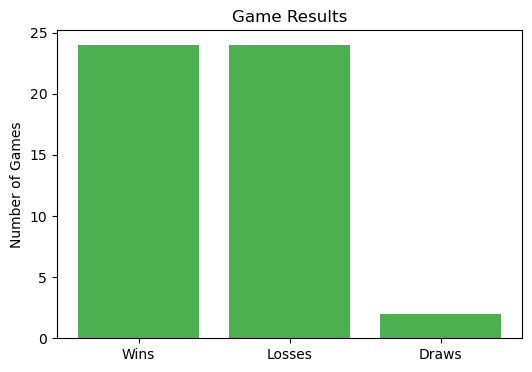

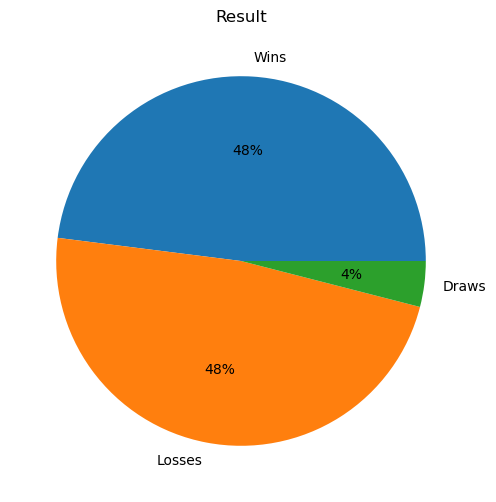

1 is win 
 0.5 is draw 
 0 is lose


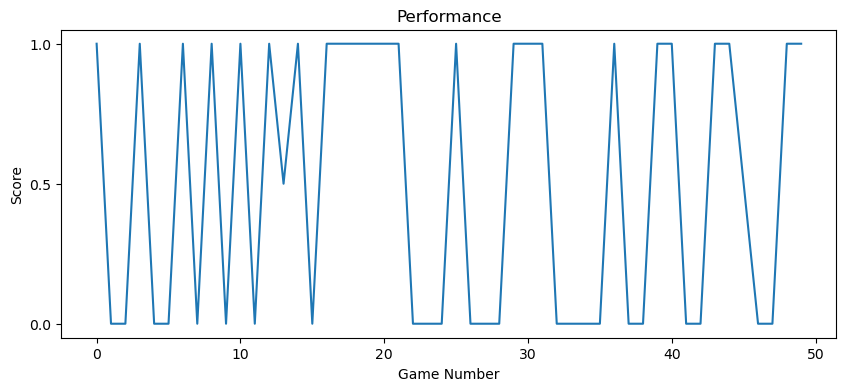

In [40]:
print("===== FINAL REPORT =====")

print(f"Total Games: {total}")
print(f"Wins: {wins}")
print(f"Losses: {losses}")
print(f"Draws: {draws}")

print(f"\n Win Rate: {win_rate:.2f}%")
print(f"White Win Rate: {white_win_rate:.2f}%")
print(f"Black Win Rate: {black_win_rate:.2f}%")

#Draw diagrams
#Bar chart

labels = ["Wins", "Losses", "Draws"]
values = [wins, losses, draws]

plt.figure(figsize=(6,4))
plt.bar(labels, values,color = "#4CAF50")

plt.title("Game Results")
plt.ylabel("Number of Games")

plt.show()
#pie chart
labels = ["Wins", "Losses", "Draws"]
values = [wins, losses, draws]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct="%1.f%%")

plt.title("Result")

plt.show()

#result plot
print(" (1) is win \n (0.5) is draw \n (0) is lose")

results_over_time = []

for _, game in df.iterrows():

    white = game["white"]
    black = game["black"]
    result = game["result"]

    if white == player_name:

        if result == "1-0":
            results_over_time.append(1)

        elif result == "1/2-1/2":
            results_over_time.append(0.5)

        else:
            results_over_time.append(0)

    elif black == player_name:

        if result == "0-1":
            results_over_time.append(1)

        elif result == "1/2-1/2":
            results_over_time.append(0.5)

        else:
            results_over_time.append(0)


plt.figure(figsize=(10,4))

plt.plot(results_over_time)

plt.title("Performance")
plt.xlabel("Game Number")
plt.ylabel("Score")

plt.yticks([0, 0.5, 1])

plt.show()

